In [1]:
# ── Step 1: RHF + CCSD on H₂ ──────────────────────────────────────────────
# PySCF gives us: MO coefficients, one-body integrals, t1/t2 amplitudes,

import numpy as np
from pyscf import gto, scf, cc

mol = gto.M(atom="H 0 0 0; H 0 0 2", basis="sto6g", unit='B', verbose=0)

mf = scf.RHF(mol)
mf.kernel()
print(f"RHF  energy: {mf.e_tot:.10f} Ha")

mycc = cc.CCSD(mf)
mycc.kernel()
print(f"CCSD energy: {mycc.e_tot:.10f} Ha")

RHF  energy: -1.0564298822 Ha
CCSD energy: -1.0960712831 Ha


In [2]:
# ── Step 2: configure JAX and define orbital dimensions ───────────────────

# import sys, os
# sys.path.insert(0, os.path.join("..", "ad_afqmc_prototype"))

from ad_afqmc_prototype import config
config.configure_once()   # enable float64, etc.

import jax
import jax.numpy as jnp

mo   = mf.mo_coeff          # (nao, norb)  MO coefficient matrix
norb = mo.shape[1]           # number of MOs
nocc = mol.nelectron // 2   # occupied MOs (closed-shell)
nvir = norb - nocc
print(f"norb={norb}  nocc={nocc}  nvir={nvir}")

norb=2  nocc=1  nvir=1


In [3]:
# my step 3 & 4 build the Hamiltonian and the trial
# just use what is availble in the code, don't do unnecessary tensor contractions

from ad_afqmc_prototype.staging import stage
from ad_afqmc_prototype.trial.rhf import RhfTrial
from ad_afqmc_prototype.ham.chol import HamChol

staged = stage(mf)

nocc = staged.meta['mol']['nelectron'] // 2

trial_data = RhfTrial(
    mo_coeff=jnp.array(staged.trial.data['mo'][:,:nocc]),
)

ham = HamChol(
    h0=jnp.array(staged.ham.h0),
    h1=jnp.array(staged.ham.h1),
    chol=jnp.array(staged.ham.chol),
    basis="restricted",
)

In [4]:
# ── Step 5: build RhfMeasCtx — precomputed measurement arrays ────────────
#
# Two arrays cached once to avoid recomputation inside the energy kernel:
#   rot_chol[g, p, q] = L^MO_{g, p<nocc, q}  (occupied-row slice of Cholesky)
#   lci1[g, p, i]     = sum_t L^MO_{g,pt} * ci1_{it}  (Cholesky × singles amplitudes)

from ad_afqmc_prototype.meas.rhf import build_meas_ctx

meas_ctx = build_meas_ctx(ham, trial_data)

print(f"rot_chol shape: {meas_ctx.rot_chol.shape}   (nchol, nocc, norb)")

rot_chol shape: (3, 1, 2)   (nchol, nocc, norb)


In [5]:
# ── Step 6: import the energy and overlap kernels ─────────────────────────

from ad_afqmc_prototype.meas.rhf import energy_kernel_rw_rh
from ad_afqmc_prototype.trial.rhf import overlap_r

In [6]:
# ── Step 7: HF reference walker — identity in the occupied block ──────────
#
# A walker is a complex (norb, nocc) Slater determinant matrix.
# The HF reference has W[:nocc, :] = I, W[nocc:, :] = 0.
#
# Green's function G = (W_occ^T)^{-1} W^T = I, so the particle-hole sector
# x = G[:, nocc:] = 0.  This makes O1 = O2 = 0, overlap = 1, and the mixed
# estimator reduces exactly to the RHF variational energy.

walker_hf     = jnp.zeros((norb, nocc), dtype=complex)
walker_hf     = walker_hf.at[:nocc, :].set(jnp.eye(nocc))

ovlp_hf = overlap_r(walker_hf, trial_data)
e_qmc    = energy_kernel_rw_rh(walker_hf, ham, meas_ctx, trial_data)

print(f"HF reference walker:")
print(f"  <Ψ_T|φ_HF>    = {ovlp_hf.real:.10f}  (imag: {ovlp_hf.imag:.1e})")
print(f"  E_QMC          = {e_qmc.real:.10f} Ha")
print(f"  HF             = {mf.e_tot:.10f} Ha")
print(f"  CCSD           = {mycc.e_tot:.10f} Ha")
# print(f"  FCI            = {e_fci:.10f} Ha")
print(f"  Δ(E_mix - HF) = {float(e_qmc.real) - mf.e_tot:+.2e} Ha")

HF reference walker:
  <Ψ_T|φ_HF>    = 1.0000000000  (imag: 0.0e+00)
  E_QMC          = -1.0564298822 Ha
  HF             = -1.0564298822 Ha
  CCSD           = -1.0960712831 Ha
  Δ(E_mix - HF) = +4.44e-16 Ha


In [20]:

# ── Propagation setup ─────────────────────────────────────────────────────
# Build the System descriptor, operation bundles (trial/meas/prop), and
# QMC hyperparameters.  All three Op objects are thin containers of callables
# that the propagation loop can call without knowing about RHF internals.

from ad_afqmc_prototype.core.system import System
from ad_afqmc_prototype.trial.rhf import make_rhf_trial_ops
from ad_afqmc_prototype.meas.rhf  import make_rhf_meas_ops
from ad_afqmc_prototype.prop.afqmc import make_prop_ops, init_prop_state
from ad_afqmc_prototype.prop.types import QmcParams
from ad_afqmc_prototype.prop.blocks import block as qmc_block

sys_obj   = System(norb=norb, nelec=(nocc, nocc), walker_kind="restricted")
rhf_trial_ops = make_rhf_trial_ops(sys_obj)
rhf_meas_ops  = make_rhf_meas_ops(sys_obj)
prop_ops  = make_prop_ops(ham.basis, sys_obj.walker_kind)

params = QmcParams(
    dt            = 0.005,   # imaginary-time step
    n_walkers     = 200,      # walker population
    n_prop_steps  = 50,      # propagation steps per block
    n_blocks      = 200,     # sampling blocks
    n_eql_blocks  = 100,      # equilibration blocks (discarded)
    seed          = 17,
)
print(f"dt={params.dt}  n_walkers={params.n_walkers}  n_prop_steps={params.n_prop_steps}")
print(f"equlibrium imaginary time: {params.n_eql_blocks * params.n_prop_steps * params.dt:.2f} a.u.")
print(f"sampling imaginary time: {params.n_blocks * params.n_prop_steps * params.dt:.2f} a.u.")


dt=0.005  n_walkers=200  n_prop_steps=50
equlibrium imaginary time: 25.00 a.u.
sampling imaginary time: 50.00 a.u.


In [21]:

# ── Initialise propagation state and precomputed contexts ─────────────────
# init_prop_state creates the walker batch from trial natural orbitals,
# computes initial overlaps, and estimates the starting energy from walker 0.
#
# build_prop_ctx precomputes:
#   exp_h1_half  = expm(-dt/2 * h1_eff)
#   mf_shifts    = i Tr[L_g * rho_0]   (mean-field shift per Cholesky vector)
#   chol_flat    = reshaped Cholesky for fast VHS construction
#
# build_meas_ctx precomputes rot_chol and lci1 (see earlier cells).

rdm1      = rhf_trial_ops.get_rdm1(trial_data)
prop_ctx  = prop_ops.build_prop_ctx(ham, rdm1, params)
meas_ctx_prop = rhf_meas_ops.build_meas_ctx(ham, trial_data)

state = init_prop_state(
    sys=sys_obj,
    ham_data=ham,
    trial_ops=rhf_trial_ops,
    trial_data=trial_data,
    meas_ops=rhf_meas_ops,
    params=params,
)

print(f"Initial walker batch shape: {state.walkers.shape}")
print(f"Initial weights (first 5):  {state.weights[:5]}")
print(f"Initial e_estimate: {float(state.e_estimate):.8f} Ha")
print(f"PYSCF-HF Energy: {float(mf.e_tot):.8f} Ha")
print(f"Initial mean |overlap|: {float(jnp.mean(jnp.abs(state.overlaps))):.6f}")


Initial walker batch shape: (200, 2, 1)
Initial weights (first 5):  [1. 1. 1. 1. 1.]
Initial e_estimate: -1.05642988 Ha
PYSCF-HF Energy: -1.05642988 Ha
Initial mean |overlap|: 1.000000


In [ ]:

# ── Equilibration ─────────────────────────────────────────────────────────
# Run n_eql_blocks blocks without recording statistics.
# Each block:
#   1. runs n_prop_steps of afqmc_step  (lax.scan inside, JIT-compiled)
#   2. QR-orthonormalises all walkers
#   3. measures the block energy (weighted mean over walkers)
#   4. updates the EMA e_estimate used in population control
#   5. performs stochastic reconfiguration (systematic resampling)
#
# The first call triggers JAX JIT compilation, which may take a few seconds.
# Subsequent blocks run much faster.
neql = 30
block_energies  = np.zeros(params.n_blocks)
block_weights   = np.zeros(params.n_blocks)
block_mean_ovlp = np.zeros(params.n_blocks)
block_times     = np.zeros(params.n_blocks)

import time

print(f"run for {params.n_blocks} blocks ...")
t0 = time.time()
dt_block = params.n_prop_steps * params.dt

for i in range(params.n_blocks):
    state, obs = qmc_block(
        state,
        sys=sys_obj,
        params=params,
        ham_data=ham,
        trial_data=trial_data,
        trial_ops=rhf_trial_ops,
        meas_ops=rhf_meas_ops,
        meas_ctx=meas_ctx_prop,
        prop_ops=prop_ops,
        prop_ctx=prop_ctx,
    )

    # e   = float(obs.scalars["energy"])
    # w   = float(obs.scalars["weight"])
    # est = float(state.e_estimate)
    # print(f"  eql {i:3d}: E={e:.8f}  total_w={w:.4f}  e_est={est:.8f}")
    block_energies[i]  = float(obs.scalars["energy"])
    block_weights[i]   = float(obs.scalars["weight"])
    # overlaps after SR are all equal; capture the post-ortho overlaps still on state
    block_mean_ovlp[i] = float(jnp.mean(jnp.abs(state.overlaps)))
    block_times[i]     = (i + 1) * dt_block

    if i > neql:
        tot_weight = jnp.sum(block_weights[neql:i+1])
        e_qmc = jnp.sum(block_weights[neql:i+1]*block_energies[neql:i+1]) / tot_weight
        e_err = jnp.sqrt(jnp.sum(block_weights[neql:i+1]*(block_energies[neql:i+1]-e_qmc)**2) / tot_weight) / jnp.sqrt(len(block_weights[neql:i+1]))
        print(f"  block {i:4d}: time={block_times[i]:.2e} E={e_qmc:.6f}  err={e_err:.6f} ")
    
    else:
        print(f"  block {i:4d}: time={block_times[i]:.2e} E={block_energies[i]:.6f}  err=--N/A-- ")

    # if i % 50 == 0 or i == params.n_blocks - 1:
    # print(f"  block {i:4d}: E={block_energies[i]:.8f}  w={block_weights[i]:.3f}  |ovlp|={block_mean_ovlp[i]:.4f}")

# print(f"Equilibration done in {time.time()-t0:.1f}s")


run for 200 blocks ...
  block    0: time=2.50e-01 E=-1.064925  err=--N/A-- 
  block    1: time=5.00e-01 E=-1.071553  err=--N/A-- 
  block    2: time=7.50e-01 E=-1.078556  err=--N/A-- 
  block    3: time=1.00e+00 E=-1.085831  err=--N/A-- 
  block    4: time=1.25e+00 E=-1.100454  err=--N/A-- 
  block    5: time=1.50e+00 E=-1.086651  err=--N/A-- 
  block    6: time=1.75e+00 E=-1.095497  err=--N/A-- 
  block    7: time=2.00e+00 E=-1.085607  err=--N/A-- 
  block    8: time=2.25e+00 E=-1.094620  err=--N/A-- 
  block    9: time=2.50e+00 E=-1.093801  err=--N/A-- 
  block   10: time=2.75e+00 E=-1.096490  err=--N/A-- 
  block   11: time=3.00e+00 E=-1.101015  err=--N/A-- 
  block   12: time=3.25e+00 E=-1.101038  err=--N/A-- 
  block   13: time=3.50e+00 E=-1.132852  err=--N/A-- 
  block   14: time=3.75e+00 E=-1.092459  err=--N/A-- 
  block   15: time=4.00e+00 E=-1.088559  err=--N/A-- 
  block   16: time=4.25e+00 E=-1.088988  err=--N/A-- 
  block   17: time=4.50e+00 E=-1.091491  err=--N/A-- 
  blo

In [18]:
e_qmc = jnp.sum(block_weights[neql:i+1]*block_energies[neql:i+1]) / tot_weight
e_err = jnp.sqrt(jnp.sum(block_weights[neql:i+1]*(block_energies[neql:i+1]-e_qmc)**2) / tot_weight) / jnp.sqrt(len(block_weights[neql:i+1]))
print(e_qmc, e_err)

-1.0931393639711402 0.0005410205131284493


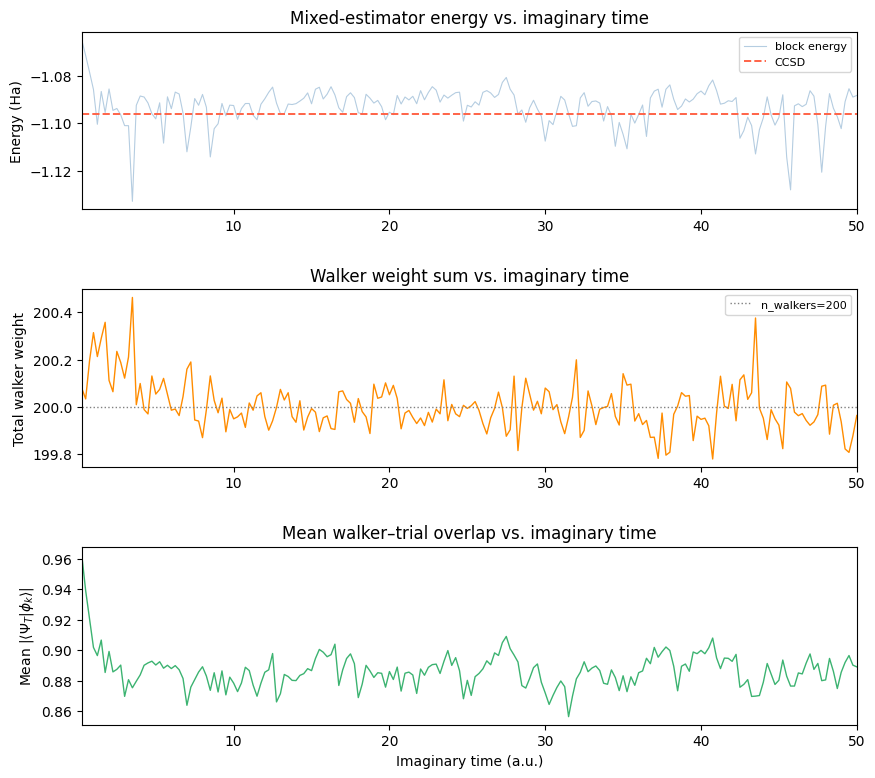

In [17]:

# ── Plot: energy, weights, overlaps vs. imaginary time ────────────────────

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(10, 9))
gs  = gridspec.GridSpec(3, 1, hspace=0.45)

# ── panel 1: block energy + cumulative mean ────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.plot(block_times, block_energies, color="steelblue", alpha=0.4, lw=0.8, label="block energy")
# ax1.plot(block_times, cum_e, color="steelblue", lw=1.8, label="cumulative mean")
ax1.axhline(mycc.e_tot, color="tomato", lw=1.4, ls="--", label="CCSD")
ax1.set_ylabel("Energy (Ha)")
ax1.set_title("Mixed-estimator energy vs. imaginary time")
ax1.legend(fontsize=8)
ax1.set_xlim(block_times[0], block_times[-1])

# shade ±1σ band around cumulative mean
sigma = np.std(block_energies) / np.sqrt(np.arange(1, params.n_blocks + 1))
# ax1.fill_between(block_times, cum_e - sigma, cum_e + sigma, color="steelblue", alpha=0.15)

# ── panel 2: total walker weight ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.plot(block_times, block_weights, color="darkorange", lw=1.0)
# after SR all weights are equalised, so total weight ~ n_walkers * avg_weight
ax2.axhline(params.n_walkers, color="grey", lw=1.0, ls=":", label=f"n_walkers={params.n_walkers}")
ax2.set_ylabel("Total walker weight")
ax2.set_title("Walker weight sum vs. imaginary time")
ax2.legend(fontsize=8)
ax2.set_xlim(block_times[0], block_times[-1])

# ── panel 3: mean |overlap| ───────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
ax3.plot(block_times, block_mean_ovlp, color="mediumseagreen", lw=1.0)
ax3.set_ylabel(r"Mean $|\langle\Psi_T|\phi_k\rangle|$")
ax3.set_xlabel("Imaginary time (a.u.)")
ax3.set_title("Mean walker–trial overlap vs. imaginary time")
ax3.set_xlim(block_times[0], block_times[-1])

plt.show()
